## Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined weather dataset
file_path = "dataset/combined_weather_data.csv"  # Replace with the actual file path if different
try:
    data = pd.read_csv(file_path)
except FileNotFoundError:
    print("The file does not exist. Please generate it first.")
    # You can use the code from earlier to generate the combined dataset

# Display the first few rows of the dataset
print(data.head())


     datetime  temp  tempmax  tempmin  humidity  precip  precipprob  \
0  2025-03-11  28.7     31.0     27.9      59.8     0.0         0.0   
1  2025-03-12  28.8     30.3     28.2      60.8     0.0         0.0   
2  2025-03-13  27.9     28.2     27.4      68.9     0.0         0.0   
3  2025-03-14  27.5     28.8     26.7      67.5     0.0         0.0   
4  2025-03-15  27.1     27.6     26.7      68.4     0.0         0.0   

   windspeed        conditions    City  
0       22.0             Clear  Mumbai  
1       25.2             Clear  Mumbai  
2       17.3             Clear  Mumbai  
3       25.2             Clear  Mumbai  
4       26.6  Partially cloudy  Mumbai  


## Perform EDA

In [2]:
print(data.isnull().sum())


print(data.dtypes)


print(data.describe())


print(data['conditions'].unique())


corr_matrix = data[['temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed']].corr()
print(corr_matrix)



datetime      0
temp          0
tempmax       0
tempmin       0
humidity      0
precip        0
precipprob    0
windspeed     0
conditions    0
City          0
dtype: int64
datetime       object
temp          float64
tempmax       float64
tempmin       float64
humidity      float64
precip        float64
precipprob    float64
windspeed     float64
conditions     object
City           object
dtype: object
             temp     tempmax     tempmin    humidity      precip  precipprob  \
count  300.000000  300.000000  300.000000  300.000000  300.000000  300.000000   
mean    29.457667   36.375667   23.484333   31.990667    0.080000    5.259333   
std      2.247639    3.260185    2.697687   20.438309    0.528328   12.879896   
min     22.300000   27.300000   14.300000    7.100000    0.000000    0.000000   
25%     28.175000   34.600000   22.000000   15.800000    0.000000    0.000000   
50%     29.200000   36.750000   23.600000   23.400000    0.000000    0.000000   
75%     31.000000   38.600

## Distribution of Temperature:

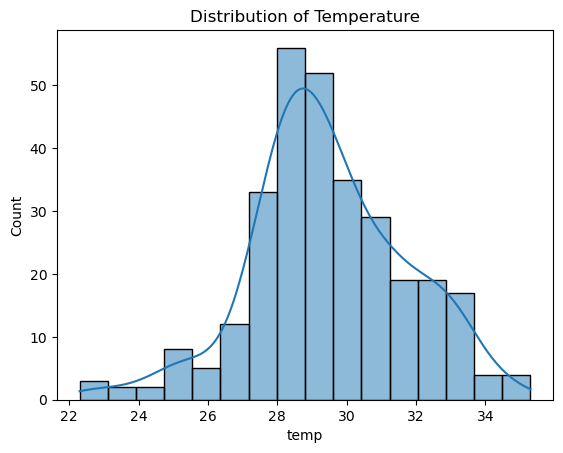

In [3]:
sns.histplot(data['temp'], kde=True)
plt.title('Distribution of Temperature')
plt.show()


## Distribution of Humidity

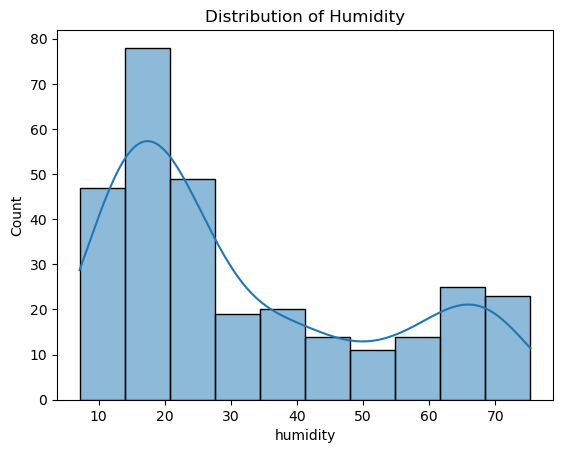

In [4]:
sns.histplot(data['humidity'], kde=True)
plt.title('Distribution of Humidity')
plt.show()


## Distribution of Precipitation:

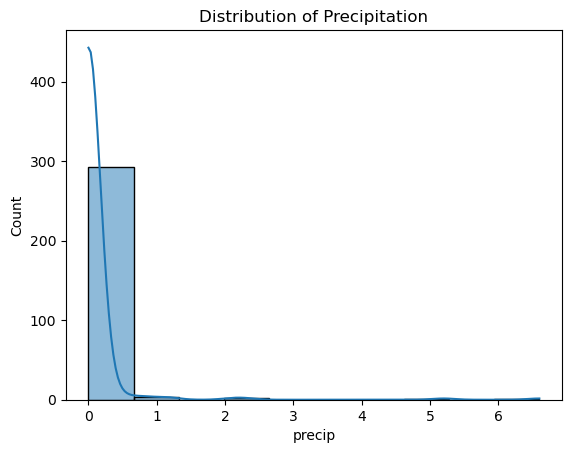

In [5]:
sns.histplot(data['precip'], kde=True)
plt.title('Distribution of Precipitation')
plt.show()


## Scatter Plot of Temperature vs. Humidity:

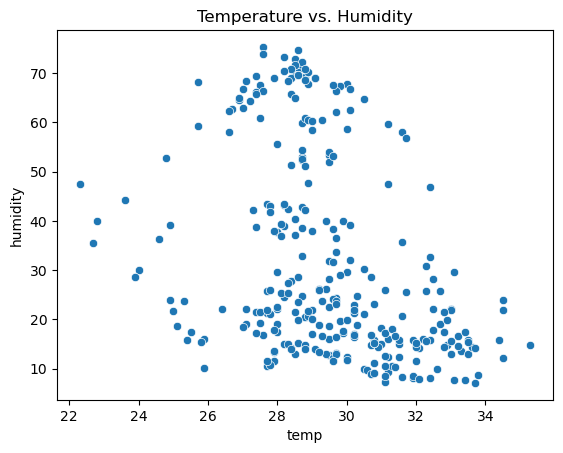

In [6]:
sns.scatterplot(x='temp', y='humidity', data=data)
plt.title('Temperature vs. Humidity')
plt.show()


## Bar Chart of Precipitation Probability by City:

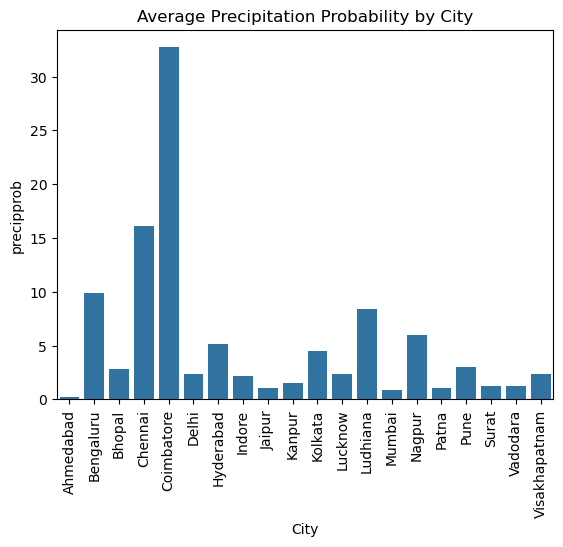

In [7]:
city_precip_prob = data.groupby('City')['precipprob'].mean().reset_index()
sns.barplot(x='City', y='precipprob', data=city_precip_prob)
plt.title('Average Precipitation Probability by City')
plt.xticks(rotation=90)
plt.show()


## Time Series Plot of Temperature:

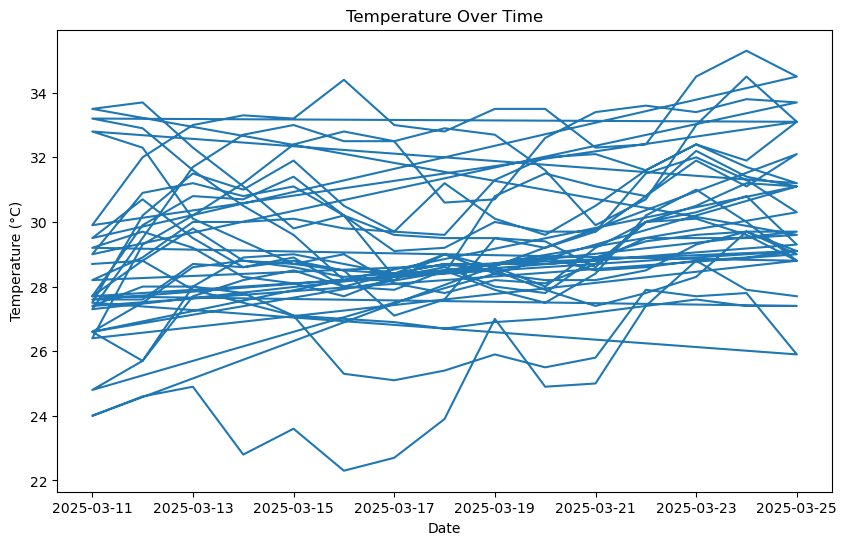

In [8]:
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)
plt.figure(figsize=(10,6))
plt.plot(data['temp'])
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()


## Box Plot of Wind Speed by City:

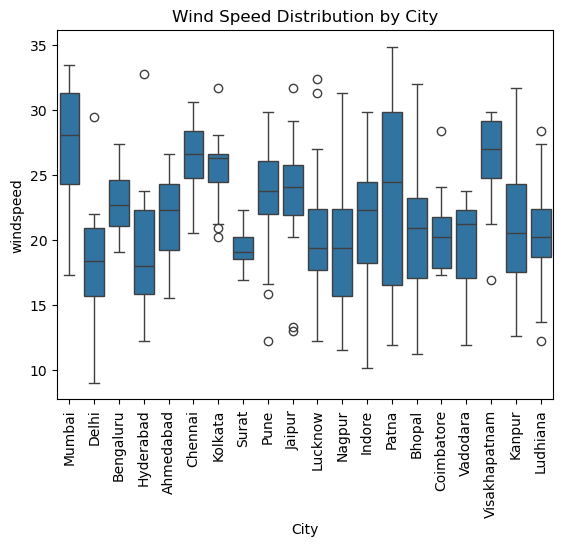

In [9]:
sns.boxplot(x='City', y='windspeed', data=data)
plt.title('Wind Speed Distribution by City')
plt.xticks(rotation=90)
plt.show()
